Metryki modelu
Accuracy:  0.856
ROC AUC:   0.757

Permutation Importance:
     feature        PI
2  D_AD_ORIT  0.009647
1  S_AD_ORIT  0.008706
5        ROE  0.001647
0        AGE  0.000941
3    K_BLOOD -0.000706
4    L_BLOOD -0.001176


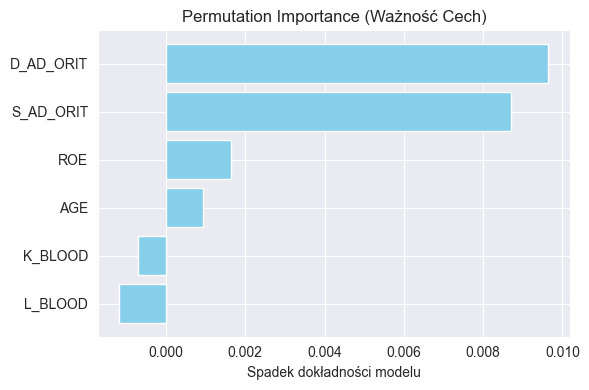

PDP i ICE


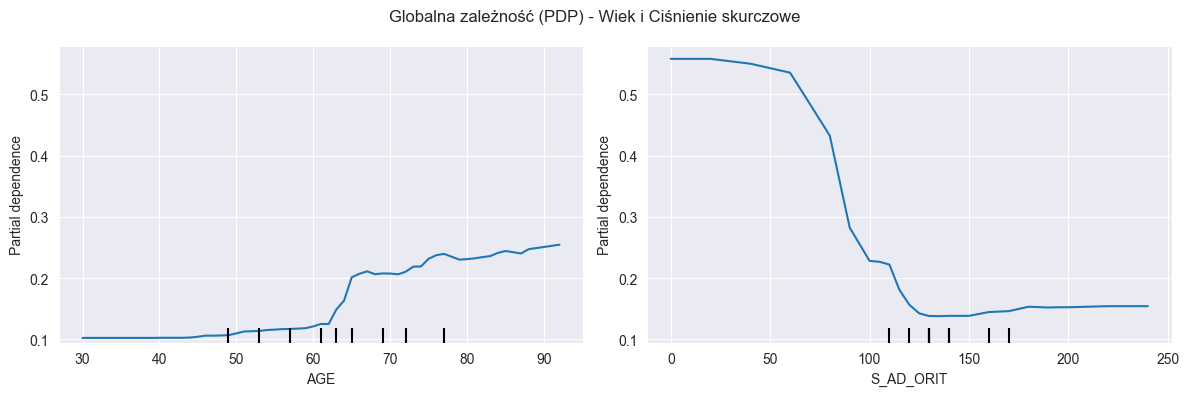

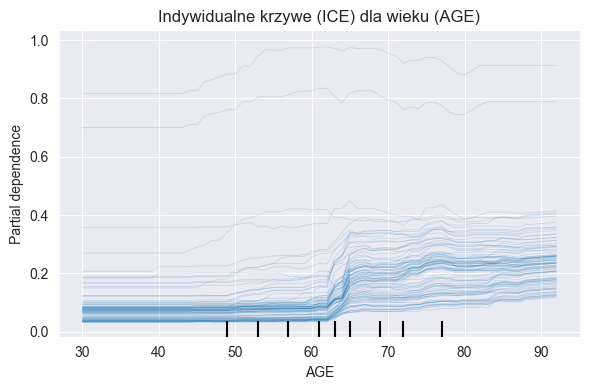

SHAP


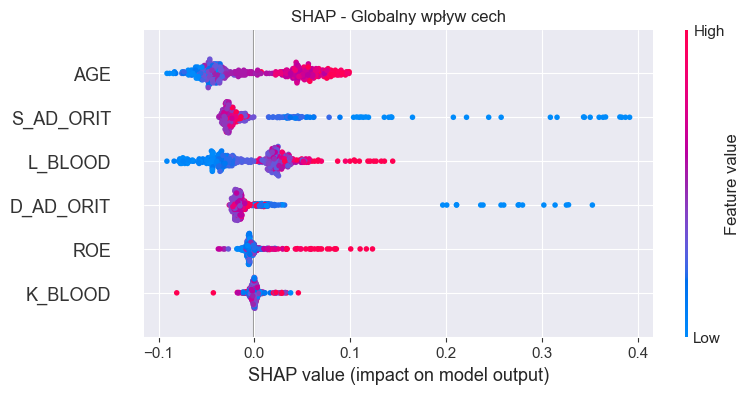

SHAP lokalny (Force Plot) dla pierwszego pacjenta w zbiorze testowym:


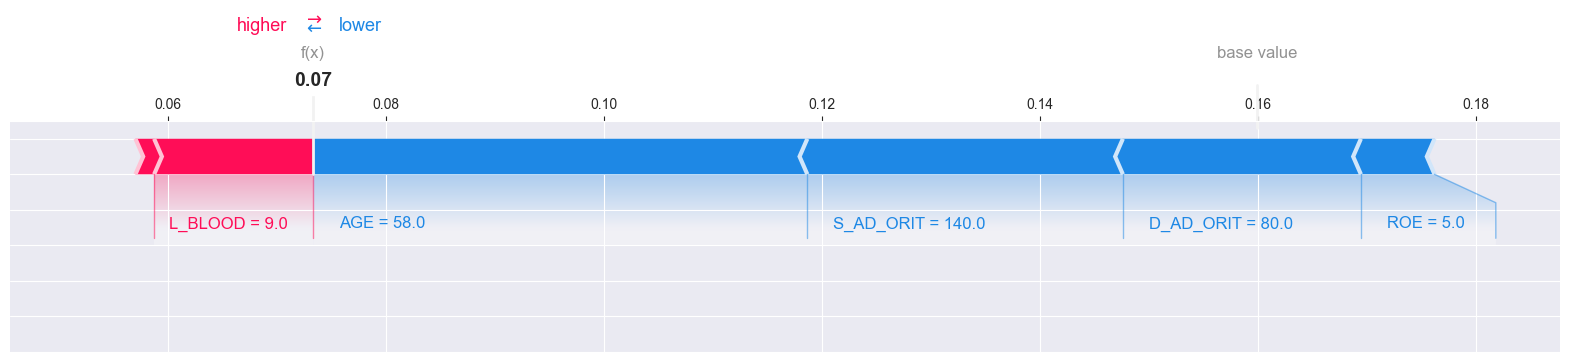


LIME
Wyjaśnienie LIME dla pacjenta 0 (Rzeczywista etykieta: Alive):
130.00 < S_AD_ORIT <= 150.00  ==>  Wpływ: -0.0479
54.00 < AGE <= 62.00  ==>  Wpływ: -0.0426
D_AD_ORIT <= 80.00  ==>  Wpływ: 0.0404
8.00 < L_BLOOD <= 10.15  ==>  Wpływ: 0.0357
ROE <= 6.00  ==>  Wpływ: -0.0200


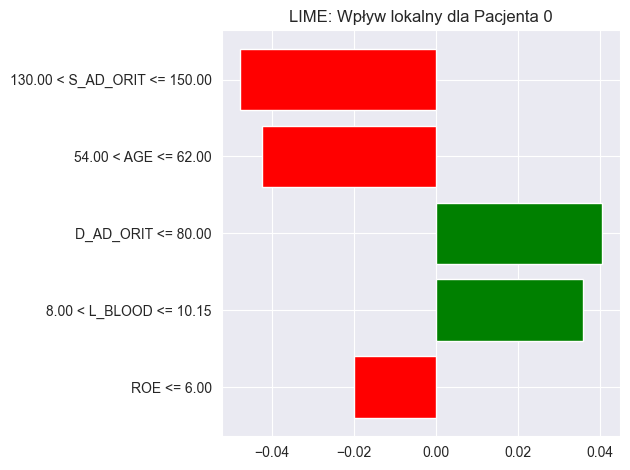

In [6]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

# 1. Wczytanie i przygotowanie danych
df = pd.read_csv('complications.csv')

# Cel: 0 - przeżycie, 1 - zgon (LET_IS > 0)
y = (df['LET_IS'].fillna(0).astype(int) > 0).astype(int)

# Wybieramy kluczowe, ciągłe cechy kliniczne
features =['AGE', 'S_AD_ORIT', 'D_AD_ORIT', 'K_BLOOD', 'L_BLOOD', 'ROE']
X = df[features].copy()

# Podział na zbiór treningowy i testowy
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# Imputacja braków danych (medianą) - LIME i SHAP wymagają danych bez NaN
imputer = SimpleImputer(strategy='median')
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=features)
X_test_imp = pd.DataFrame(imputer.transform(X_test), columns=features)

# 2. Trenowanie modelu
clf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
clf.fit(X_train_imp, y_train)

# Metryki binarne
proba = clf.predict_proba(X_test_imp)[:, 1]
pred = clf.predict(X_test_imp)
print(f"Metryki modelu")
print(f"Accuracy:  {accuracy_score(y_test, pred):.3f}")
print(f"ROC AUC:   {roc_auc_score(y_test, proba):.3f}\n")

# 3. Permutation Importance (PI)
print("Permutation Importance:")
pi = permutation_importance(clf, X_test_imp, y_test, n_repeats=10, random_state=42)
imp_df = pd.DataFrame({"feature": features, "PI": pi.importances_mean}).sort_values("PI", ascending=False)
print(imp_df)

plt.figure(figsize=(6, 4))
plt.barh(imp_df["feature"], imp_df["PI"], color='skyblue')
plt.title("Permutation Importance (Ważność Cech)")
plt.xlabel("Spadek dokładności modelu")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# 4. Partial Dependence Plots (PDP) i ICE
print("PDP i ICE")
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
PartialDependenceDisplay.from_estimator(clf, X_test_imp, features=["AGE", "S_AD_ORIT"], kind="average", ax=ax)
plt.suptitle("Globalna zależność (PDP) - Wiek i Ciśnienie skurczowe")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
PartialDependenceDisplay.from_estimator(clf, X_test_imp, features=["AGE"], kind="individual", subsample=100, ax=ax, line_kw={"alpha": 0.2})
plt.title("Indywidualne krzywe (ICE) dla wieku (AGE)")
plt.tight_layout()
plt.show()

# 5. SHAP
try:
    import shap
    print("SHAP")
    explainer = shap.TreeExplainer(clf)
    shap_values = explainer.shap_values(X_test_imp)

    # Zabezpieczenie dla różnych wersji SHAP (lista lub 3D numpy array)
    if isinstance(shap_values, list):
        shap_values_class1 = shap_values[1]
    elif len(np.shape(shap_values)) == 3:
        shap_values_class1 = shap_values[:, :, 1]
    else:
        shap_values_class1 = shap_values

    # Bezpieczne pobranie base_value
    if isinstance(explainer.expected_value, (list, np.ndarray)) and len(np.shape(explainer.expected_value)) > 0:
        base_val = explainer.expected_value[1]
    else:
        base_val = explainer.expected_value

    shap.summary_plot(shap_values_class1, X_test_imp, feature_names=features, show=False)
    plt.title("SHAP - Globalny wpływ cech")
    plt.show()

    # Force plot dla pacjenta nr 0 ze zbioru testowego
    print("SHAP lokalny (Force Plot) dla pierwszego pacjenta w zbiorze testowym:")
    shap.force_plot(base_val, shap_values_class1[0,:], X_test_imp.iloc[0,:], matplotlib=True)
    plt.show()
except Exception as e:
    print("SHAP błąd/niedostępny:", e)

# 6. LIME
try:
    from lime.lime_tabular import LimeTabularExplainer
    print("\nLIME")
    lime_explainer = LimeTabularExplainer(
        training_data=X_train_imp.values,
        feature_names=features,
        class_names=["Alive", "Lethal"],
        discretize_continuous=True,
        mode="classification"
    )
    # Wyjaśniamy predykcję dla pierwszego pacjenta ze zbioru testowego
    exp = lime_explainer.explain_instance(X_test_imp.values[0], clf.predict_proba, num_features=5)
    print(f"Wyjaśnienie LIME dla pacjenta 0 (Rzeczywista etykieta: {'Lethal' if y_test.iloc[0] == 1 else 'Alive'}):")
    for feat, val in exp.as_list(label=1):
        print(f"{feat}  ==>  Wpływ: {val:.4f}")
    exp.as_pyplot_figure()
    plt.title("LIME: Wpływ lokalny dla Pacjenta 0")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("LIME niedostępny:", e)